# Elife Paper 

## Figure 4: Need for Nightly jumps 
1. With jumps - C, D, E
2. Without jumps - A, B
3. F: Comparing their success
### Reward Landscapes

In [1]:
# import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import json
import pickle
# import queue
from scipy.integrate import solve_ivp
from dual_pathway_model.functions import *
from dual_pathway_model.plotting_functions import *
from dual_pathway_model.directory_functions import *
from dual_pathway_model.model import NN, Environment, params_base
import time

%load_ext autoreload


Testing
Plotting colors safely loaded
Base parameters loaded from params.yaml


In [2]:
# # load parameters from json file

# params_path = "params_4_jumps.json"
# # Open the file and read the contents
# with open(params_path, "r") as f:
#     parameters = json.load(f)
# running conditions

parameters = update_params(params_base,
                           **{
                            
                               'params.RECORD_WEIGHTS':  1
                            #    'params.BG_NOISE': 0.3 # original is 0.2 
                           } )

N_DAILY_MOTIFS = parameters['params']['TRIALS'] # trials per day per syllable  # old code TRIALS
TRIALS = N_DAILY_MOTIFS
BG_INTACT_DAYS = parameters['params']['BG_INTACT_DAYS']
DAYS = parameters['params']['DAYS'] # days for learning
N_SYLL = parameters['params']['N_SYLL'] # number of syllables   
if N_SYLL > 5 or N_SYLL < 1:
    ValueError('Invalid number of syllables')
RANDOM_SEED = 25495 # 53410 # int(time.time() * 1000) % 100000  # system-time-based seed
#42 # originally 40 # 13074 # 83283 # 44254
ANNEALING = parameters['params']['ANNEALING'] # annealing 
              
print(f'Random seed is {RANDOM_SEED}')

Random seed is 25495


In [3]:
# --------------------
# Config
# --------------------
MODEL_DIR = "models"
model_version = "model_4a" # 
model_path = os.path.join(MODEL_DIR, f"{model_version}.pkl")
overwrite_model = False # whether to overwrite existing model or not
save_model = False # whether to save model after running simulation or not
# --------------------
# Ensure models/ exists
# --------------------
os.makedirs(MODEL_DIR, exist_ok=True)

print(parameters['params']['JUMP_FACTOR'])
print(parameters['params']['JUMP_MID'])

# --------------------
# Load / run / overwrite logic
# --------------------
if os.path.exists(model_path):
    print(f"Model '{model_version}' already exists.")
    if not overwrite_model:
        print("Loading existing model...")
        with open(model_path, "rb") as f:
            obj_4a = pickle.load(f)
        print(f"Loaded model '{model_version}'")
    else:
        print("Overwrite enabled. Re-running simulation and overwriting model...")
        print(f"Model '{model_version}' not found. Running simulation...")
        obj_4a = Environment(RANDOM_SEED, parameters, NN)
        obj_4a.run(parameters)
        if save_model:
            with open(model_path, "wb") as f:
                pickle.dump(obj_4a, f)
            print(f"Saved model '{model_version}' to '{model_path}'")
else:
    print(f"Model '{model_version}' not found. Running simulation...")
    obj_4a = Environment(RANDOM_SEED, parameters, NN)
    obj_4a.run(parameters)
    if save_model:
        with open(model_path, "wb") as f:
            pickle.dump(obj_4a, f)
        print(f"Saved model '{model_version}' to '{model_path}'")



4
0.25
Model 'model_4a' not found. Running simulation...


100%|██████████| 60/60 [00:29<00:00,  2.04it/s]


In [4]:
jumps_hvc_bg = obj_4a.hvc_bg_array_all

### All functions for figures. Labelled below.

### A, C

In [5]:

chosen_syll = 2
save_figs = False

C:\Users\aSuryawanshi\Documents\Codes\Dual_Pathway_RL_songbird\src\dual_pathway_model\plotting_functions.py:232: UserWarning: The following kwargs were not used by contour: 'aspect'
  cs = axs.contourf(Z, cmap=cmap, extent=[-limit, limit, -limit, limit], aspect='equal', vmin=0, vmax=1, levels=levels_, alpha=contour_alpha)


Plotting artificial landscape


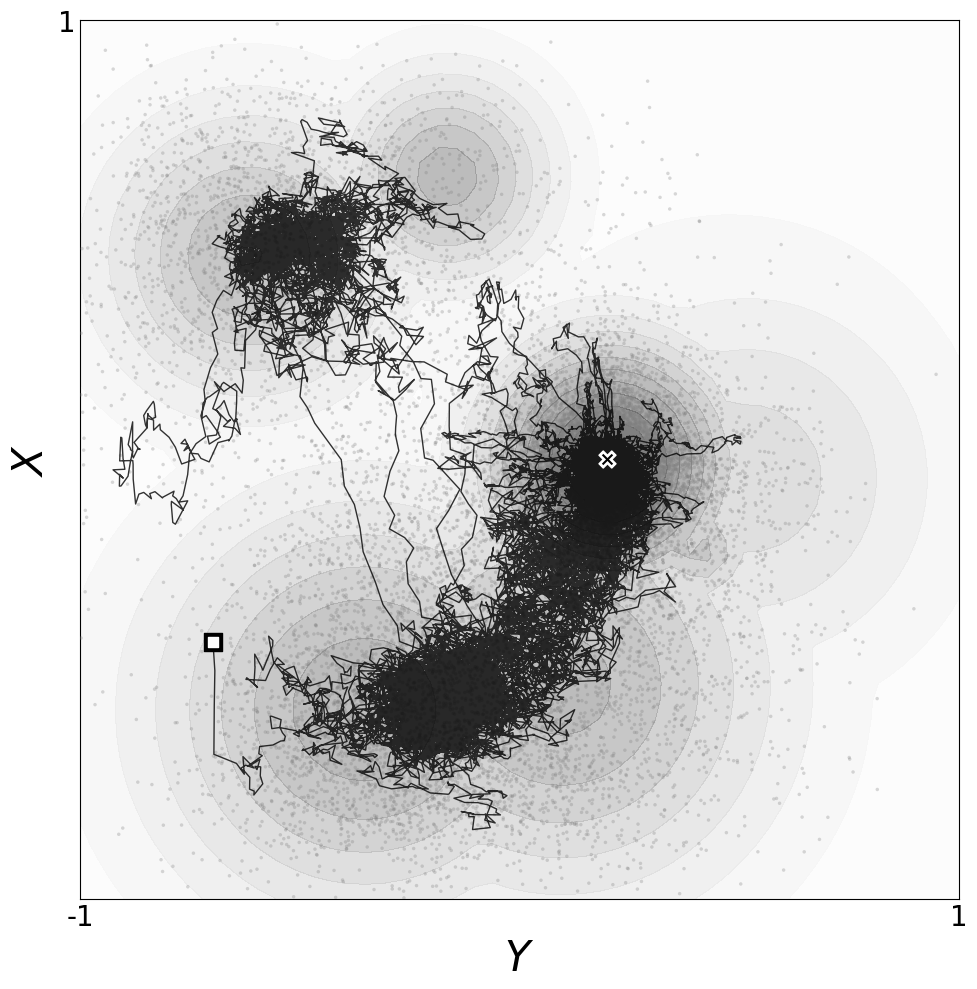

In [6]:
%autoreload 2
from dual_pathway_model.plotting_functions import *

# for chosen_syll in range(N_SYLL):
plot_scatter_traj(obj = obj_4a, syll=chosen_syll, day_i=0, day_f=60, every_nth_point=2, scatter_alpha=0.3, if_contour=False, contour_alpha=.5, heatmap=True,
                plot_smooth_traj=True)  # To remove smoothened trajectory, set plot_smooth_traj=False

save_figure(f"4d_traj_w_jump", save=save_figs)

In [7]:
# def plot_spec_avg_traj(obj, syll, day_i, day_f, N_i, N_f, steepness = 5.0):
#     fig, axs = plt.subplots(figsize=(9, 9))
#     cmap = color_contour_bckg  # Match the colormap style from plot_landscape
#     levels_ = 50

#     def plot_artificial():
#         limit = obj.limit
#         x, y = np.linspace(-limit, limit, 50), np.linspace(-limit, limit, 50)
#         X, Y = np.meshgrid(x, y)
#         Z = obj.get_reward([X, Y], syll)
#         contour = axs.contourf(X, Y, Z, levels=levels_, cmap=cmap)
#         if if_contour:
#             axs.contour(X, Y, Z, levels=15, colors='k', linewidths=1, alpha=0.9)
#         # cbar = fig.colorbar(contour, ax=axs)
#         # cbar.set_label('Performance Metric (R)', fontsize=20, rotation=270)
#         # cbar.ax.tick_params(labelsize=18)
#         # cbar.ax.set_yticks([0, 1])
#         axs.set_xticks([-limit, 0, limit], [-1, 0, 1])
#         axs.set_yticks([-limit, 0, limit], [-1, 0, 1])

#     def plot_syrinx():
#         if obj.N_SYLL > 4:
#             raise ValueError('Only 4 syllables are available in the syrinx landscape')
#         obj.syrinx_contours = []
#         obj.syrinx_targets = []
#         for j in range(obj.N_SYLL):
#             base = np.load(f"contours/Syll{j+1}.npy")
#             Z, target = make_contour(base)
#             obj.syrinx_contours.append(Z)
#             obj.syrinx_targets.append(target)
#         obj.centers = np.array(obj.syrinx_targets)
#         obj.syrinx_contours = np.array(obj.syrinx_contours)
#         Z = obj.syrinx_contours[syll]
#         target_pos = obj.syrinx_targets[syll]
#         if if_contour:
#             axs.contour(Z.T, levels=20, extent=[-1, 1, -1, 1], colors='k', linewidths=1, alpha=0.5)
#         cs = axs.contourf(Z.T, cmap=cmap, extent=[-1, 1, -1, 1], levels=levels_)
#         # cbar = fig.colorbar(cs, ax=axs)
#         # cbar.set_label('Performance Metric (R)', fontsize=20, rotation=270)
#         # cbar.ax.tick_params(labelsize=18)
#         # cbar.ax.set_yticks([0, 1])
#         axs.set_xticks([-1, 0, 1], [-1, 0, 1])
#         axs.set_yticks([-1, 0, 1], [-1, 0, 1])
#         # axs.scatter(target_pos[1], target_pos[0], s=100, c='green', marker='x', label='Target')

#     # Plot background landscape
#     if obj.LANDSCAPE == 0:
#         plot_artificial()
#     else:
#         plot_syrinx()

#     # Plot agent trajectory
#     x_traj, y_traj = zip(*obj.actions[:, :, syll, :].reshape(-1, 2))
#     # xtraj_smooth = running_mean(np.array(x_traj), N=every_nth_point)
#     # ytraj_smooth = running_mean(np.array(y_traj), N=every_nth_point)
#     xtraj_smooth = running_mean_dynamic(np.array(x_traj), N_i=N_i, N_f=N_f, steepness=steepness)
#     ytraj_smooth = running_mean_dynamic(np.array(y_traj), N_i=N_i, N_f=N_f, steepness=steepness)
#     axs.plot(
#         xtraj_smooth[day_i * TRIALS: day_f * TRIALS], #[::every_nth_point],
#         ytraj_smooth[day_i * TRIALS: day_f * TRIALS],#[::every_nth_point],
#         color = color_motor, label='Agent Trajectory', alpha=0.5, linewidth=1, marker='.', markersize=1
#     )

#     # axs.scatter(x_traj[0], y_traj[0],
#     #             s=200, c='yellow', edgecolors='black',
#     #             marker='o', linewidths=2, zorder=3, label='Starting Point')
#     # axs.text(x_traj[0] + 0.1, y_traj[0] + 0.1, 'Start', fontsize=15, ha='center', va='bottom')
#     # axs.text(x_traj[-1] + 0.1, y_traj[-1] + 0.1, 'End', fontsize=15, ha='center', va='bottom')
#     # axs.scatter(x_traj[-1], y_traj[-1],
#     #             s=200, c='red', edgecolors='black',
#     #             marker='o', linewidths=2, zorder=4, label='Ending Point')
#     axs.scatter(xtraj_smooth[day_i * TRIALS: day_f * TRIALS][0], ytraj_smooth[day_i * TRIALS: day_f * TRIALS][0],
#                 s=150, c='black',
#                 marker='s', zorder=5, label='Starting Point')
#     axs.scatter(xtraj_smooth[day_i * TRIALS: day_f * TRIALS][-1], ytraj_smooth[day_i * TRIALS: day_f * TRIALS][-1],
#                 s=150, c='white',
#                 marker='X', zorder=5, label='Ending Point')
#     axs.scatter(xtraj_smooth[day_i * TRIALS: day_f * TRIALS][0], ytraj_smooth[day_i * TRIALS: day_f * TRIALS][0],
#                 s=50, c='white',
#                 marker='s', zorder=6, label='Starting Point')
#     axs.scatter(xtraj_smooth[day_i * TRIALS: day_f * TRIALS][-1], ytraj_smooth[day_i * TRIALS: day_f * TRIALS][-1],
#                 s=50, c='black',
#                 marker='x', zorder=6, label='Ending Point')

#     # Labels
#     axs.set_ylabel(r'$P$', fontsize=22)
#     axs.set_xlabel(r'$Tt$', fontsize=22)
#     # axs.set_ylabel(r'$P_{\alpha}$ (Pressure)', fontsize=22)
#     # axs.set_xlabel(r'$P_{\beta}$ (Tension)', fontsize=22)
#     axs.tick_params(labelsize=16)
#     # axs.legend()
#     plt.tight_layout()
#     plt.show()


### B, D

In [8]:
def plot_reward_with_zoom(obj, main_first_day=0, main_last_day=60,
                          zoom1_first_day=5, zoom1_last_day=7, offset1 = 0.3,
                          zoom2_first_day=20, zoom2_last_day=22, offset2 = 0.3,
                          syll=0, if_inset = True):

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    array = obj.rewards[:, :, syll].reshape(DAYS * N_DAILY_MOTIFS)

    # Main plot segment
    start_main = main_first_day * N_DAILY_MOTIFS
    end_main = main_last_day * N_DAILY_MOTIFS
    segment_main = array[start_main:end_main]
    every_nth = 20

    # Plot raw reward (main)
    ax.plot(np.arange(start_main, end_main, every_nth), segment_main[::every_nth],
            marker='.', linestyle='None', alpha=0.5, markersize=1, color=color_reward)

    # Plot running mean (main)
    smooth_main = running_mean(segment_main, 300)
    smooth_x_main = np.arange(start_main, end_main)
    ax.plot(smooth_x_main, smooth_main, lw=1.5, alpha=0.9, color=color_reward)

    ax.set_xlabel('DPH', fontsize=18)
    ax.set_ylabel('Performance metric (R)', fontsize=18)
    ax.set_ylim(0, 1)
    ax.tick_params(labelsize=12)
    ax.set_yticks([0, 1])
    ax.set_xticks(np.arange(start_main, end_main + 1, 10 * N_DAILY_MOTIFS),
                  40 + np.arange(main_first_day, main_last_day + 1, 10))
    ax.set_xlim(start_main, end_main)
    ax.axvline(x=BG_INTACT_DAYS * TRIALS, ymin=0, ymax=1.2,
               linestyle=':', color='grey', lw=1, label='Lesion')
    # Vertical lines for every day
    for day in range(main_first_day, main_last_day + 1):
        ax.axvline(x=day * N_DAILY_MOTIFS, linestyle=':', color='grey', lw=0.5)
    if if_inset:    # === Zoom Inset 1 === #
        axins1 = inset_axes(ax, width="15%", height="50%",
                                bbox_to_anchor=(0.2, 0.65, 1, 1),
                                bbox_transform=ax.transAxes, loc='upper left',
                                borderpad=0)

        start1 = zoom1_first_day * N_DAILY_MOTIFS
        end1 = zoom1_last_day * N_DAILY_MOTIFS
        seg1 = array[start1:end1]

        axins1.plot(np.arange(start1, end1), seg1, marker='.', linestyle='None',
                        alpha=0.2, markersize=2, color=color_reward)
        smooth1 = running_mean(seg1, 300)
        axins1.plot(np.arange(start1, end1)[::1], smooth1[::1], lw=1.5, alpha=0.9, color=color_reward)
        axins1.set_xlim(start1, end1)
        ylim_lower = smooth1.min() + offset1
        ylim_upper = smooth1.min() + offset1 + 0.5
        axins1.set_ylim(ylim_lower, ylim_upper)
        axins1.set_yticks([np.ceil(ylim_lower*10)/10, np.floor(ylim_upper*10)/10])
        # axins1.set_xticks([])
        # axins1.set_yticks([])
        axins1.set_ylabel('R', fontsize=12)
        axins1.set_xticks(np.arange(start1, end1 + 1, 1 * N_DAILY_MOTIFS),
                    40 + np.arange(zoom1_first_day, zoom1_last_day + 1, 1))
        for day in range(zoom1_first_day, zoom1_last_day + 1):
            axins1.axvline(x = day*TRIALS, ymin=0, ymax=1, color = 'black', lw=0.5)

        # === Zoom Inset 2 === #
        axins2 = inset_axes(ax, width="15%", height="50%",
                                bbox_to_anchor=(0.6, 0.65, 1, 1),
                                bbox_transform=ax.transAxes, loc='upper left',
                                borderpad=0)

        start2 = zoom2_first_day * N_DAILY_MOTIFS
        end2 = zoom2_last_day * N_DAILY_MOTIFS
        seg2 = array[start2:end2]

        axins2.plot(np.arange(start2, end2), seg2, marker='.', linestyle='None',
                        alpha=0.2, markersize=2, color=color_reward)
        smooth2 = running_mean(seg2, 100)
        axins2.plot(np.arange(start2, end2)[::10], smooth2[::10], lw=1.5, alpha=0.9, color=color_reward)
        axins2.set_xlim(start2, end2)
        # axins2.set_ylim(0.0, 1.0)
        # axins2.set_xticks([])
        # axins2.set_yticks([])
        # axins2.set_ylabel('R', fontsize=12)
        axins2.set_xticks(np.arange(start2, end2 + 1, 1 * N_DAILY_MOTIFS),
                    40 + np.arange(zoom2_first_day, zoom2_last_day + 1, 1))
        ylim_lower = smooth2.min() + offset2
        ylim_upper = smooth2.min() + offset2 + 0.5
        axins2.set_ylim(ylim_lower, ylim_upper)
        axins2.set_yticks([np.ceil(ylim_lower*10)/10, np.floor(ylim_upper*10)/10])
        for day in range(zoom2_first_day, zoom2_last_day + 1):
            axins2.axvline(x = day*TRIALS, ymin=0, ymax=1.2, color = 'black', lw=0.5)

        # Indicate zoom regions
        ax.indicate_inset_zoom(axins1, edgecolor="black", alpha=1, lw=0.5, )
        ax.indicate_inset_zoom(axins2, edgecolor="black", alpha=1, lw=0.5)

    plt.tight_layout()
    # plt.show()




### E

In [9]:

def plot_BG_volatility(obj, zoom_start=200, zoom_end=400, offset=0):
    figure, ax1 = plt.subplots(1, figsize=(10, 4))

    every_nth = 20
    # Main plot

    segment_main = obj.bg_out[:,:,1].reshape((DAYS)*N_DAILY_MOTIFS)
    ax1.plot(np.arange(0, (DAYS)*N_DAILY_MOTIFS, every_nth), segment_main[::every_nth],
        marker='.', linestyle='None', alpha=0.5, markersize=1, color=color_bg)

    bg_trace = running_mean(segment_main,50)
    ax1.plot(bg_trace, color=color_bg, alpha=0.8, linewidth=2)
    # ax1.axvline(x=N_DAYS_INTACT * N_DAILY_MOTIFS, linestyle='--', color='grey', lw=1)     
    [ax1.axvline(x=k, linestyle='-', color='black', alpha=0.1) 
     for k in range(0, DAYS*N_DAILY_MOTIFS, N_DAILY_MOTIFS)]    

    # Axis settings
    ax1.set_xlabel('DPH', fontsize=20)
    ax1.set_ylabel('HVC-BG\nsynaptic strength', fontsize=20)
    ax1.set_ylim(-1, 1)
    ax1.set_yticks([-1, 0, 1])
    ax1.tick_params(labelsize=15)
    ax1.set_xlim(-N_DAILY_MOTIFS, DAYS*N_DAILY_MOTIFS)   
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.spines['bottom'].set_bounds(0, DAYS*N_DAILY_MOTIFS)
    plt.xticks(range(0, N_DAILY_MOTIFS*(DAYS+1), 20*N_DAILY_MOTIFS), 
               np.arange(40, 40+DAYS+1, 20))    

    # === Inset Zoom ===
    zoom_ax = inset_axes(ax1, width="15%", height="50%", 
                                bbox_to_anchor=(-0.3, 0.65, 1, 1),
                                bbox_transform=ax1.transAxes,
                                loc="upper right", 
                                borderpad=0)
    zoom_ax.plot(np.arange(0, (DAYS)*N_DAILY_MOTIFS, every_nth), segment_main[::every_nth],
        marker='.', linestyle='None', alpha=0.5, markersize=1, color=color_bg)

    zoom_ax.plot(bg_trace, color=color_bg, linewidth=1.5)

    # Zoomed region limits
    zoom_ax.set_xlim(zoom_start, zoom_end)
    
    ylim_lower = bg_trace.min() + offset
    ylim_upper = bg_trace.min() + offset + 1
    zoom_ax.set_ylim(ylim_lower, ylim_upper)
    zoom_ax.set_yticks([np.ceil(ylim_lower*10)/10, np.floor(ylim_upper*10)/10])
    zoom_ax.set_xticks([zoom_start, zoom_start + N_DAILY_MOTIFS, zoom_end])
    zoom_ax.set_xticklabels([f" {zoom_start//TRIALS + 40 }", f" {zoom_start//TRIALS + 40 + 1 }", f" {zoom_end//TRIALS + 40}"])
    zoom_ax.tick_params(labelsize=10)
    for day in range(zoom_start//TRIALS, zoom_end//TRIALS + 1):
        zoom_ax.axvline(x = day*TRIALS, ymin=-1, ymax=1, color = 'black', lw=0.5)

    # Add rectangle + connectors
    mark_inset(ax1, zoom_ax, loc1=2, loc2=4, fc="none", ec="black", lw=1)

    plt.tight_layout()
    # plt.show()



### With Night jumps

C:\Users\aSuryawanshi\AppData\Local\Temp\ipykernel_27080\897934956.py:99: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


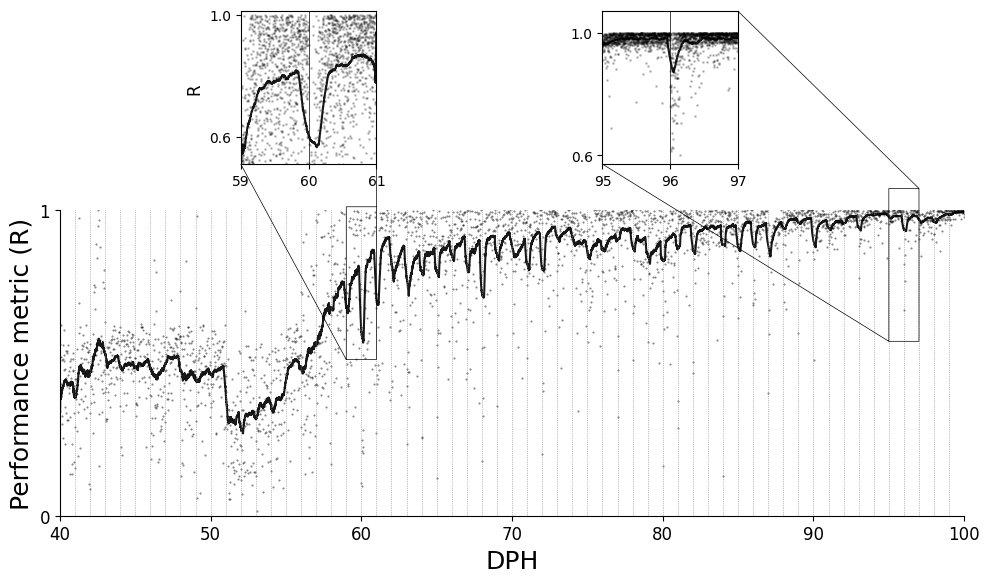

In [10]:
# plot_spec_avg_traj(obj_4a, syll = 2, day_i = 0, day_f = 60, N_i = 1, N_f = 2000, steepness = 20)
# for chosen_syll in range(N_SYLL):
plot_reward_with_zoom(obj_4a, main_first_day=0, main_last_day=60, zoom1_first_day=19, zoom1_last_day=21, offset1=0, zoom2_first_day=55, zoom2_last_day=57, offset2=-0.3, syll=chosen_syll, if_inset = True)
save_figure(f"4e_reward_w_jump", save=save_figs)

C:\Users\aSuryawanshi\AppData\Local\Temp\ipykernel_27080\1376028525.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


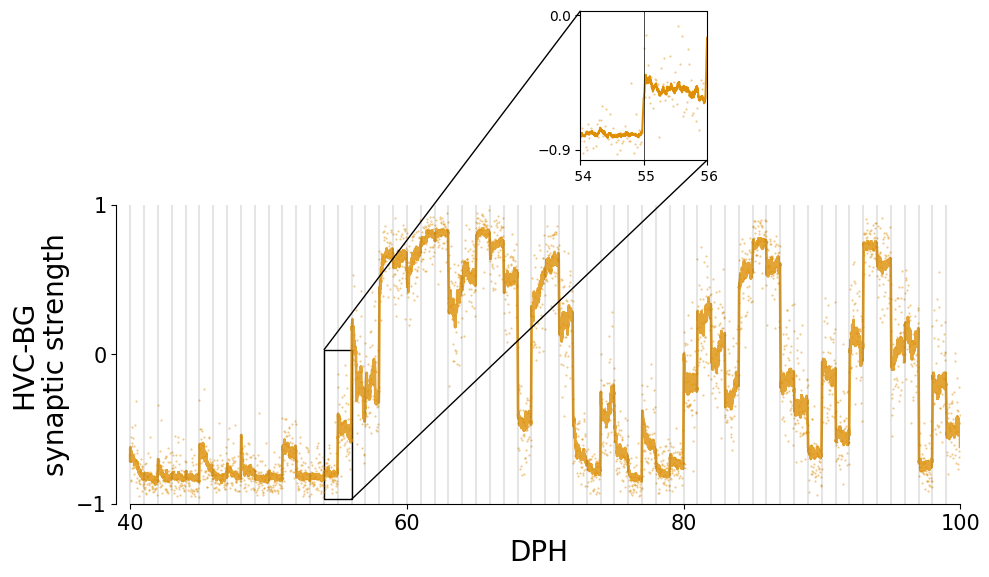

In [11]:
plot_BG_volatility(obj_4a, zoom_start=14000, zoom_end=16000, offset=-.1)
save_figure(f"4f_HVC-BG_w_jump", save=save_figs)

### Without nightly jumps

In [12]:
# # load parameters from json file
# params_path = "params_4_nojumps.json"
# # Open the file and read the contents
# with open(params_path, "r") as f:
#     parameters = json.load(f)
parameters = update_params(params_base,
                           **{
                               "params.ANNEALING": 0,
                               'params.RECORD_WEIGHTS':  1
                           } )
# running conditions
N_DAILY_MOTIFS = parameters['params']['TRIALS'] # trials per day per syllable  # old code TRIALS
TRIALS = N_DAILY_MOTIFS
BG_INTACT_DAYS = parameters['params']['BG_INTACT_DAYS']
DAYS = parameters['params']['DAYS'] # days for learning
N_SYLL = parameters['params']['N_SYLL'] # number of syllables   
if N_SYLL > 5 or N_SYLL < 1:
    ValueError('Invalid number of syllables')
RANDOM_SEED = RANDOM_SEED #40
ANNEALING = parameters['params']['ANNEALING'] # annealing 
print(ANNEALING)                  
print(f'Random seed is {RANDOM_SEED}')

# --------------------
# Config
# --------------------
MODEL_DIR = "models"
model_version = "model_4b" # 
model_path = os.path.join(MODEL_DIR, f"{model_version}.pkl")
overwrite_model = False # whether to overwrite existing model or not
save_model = False # whether to save model after running simulation or not
# --------------------
# Ensure models/ exists
# --------------------
os.makedirs(MODEL_DIR, exist_ok=True)

# --------------------
# Load / run / overwrite logic
# --------------------
if os.path.exists(model_path):
    print(f"Model '{model_version}' already exists.")
    if not overwrite_model:
        print("Loading existing model...")
        with open(model_path, "rb") as f:
            obj_4b = pickle.load(f)
        print(f"Loaded model '{model_version}'")
    else:
        print("Overwrite enabled. Re-running simulation and overwriting model...")
        print(f"Model '{model_version}' not found. Running simulation...")
        obj_4b = Environment(RANDOM_SEED, parameters, NN)
        obj_4b.run(parameters)
        if save_model:
            with open(model_path, "wb") as f:
                pickle.dump(obj_4b, f)
            print(f"Saved model '{model_version}' to '{model_path}'")
else:
    print(f"Model '{model_version}' not found. Running simulation...")
    obj_4b = Environment(RANDOM_SEED, parameters, NN)
    obj_4b.run(parameters)
    if save_model:
        with open(model_path, "wb") as f:
            pickle.dump(obj_4b, f)
        print(f"Saved model '{model_version}' to '{model_path}'")


0
Random seed is 25495
Model 'model_4b' not found. Running simulation...


100%|██████████| 60/60 [00:30<00:00,  1.98it/s]


In [13]:
no_jumps_hvc_bg = obj_4b.hvc_bg_array_all

In [14]:
no_jumps_hvc_bg[0].shape

(1000, 4, 100, 50)

C:\Users\aSuryawanshi\Documents\Codes\Dual_Pathway_RL_songbird\src\dual_pathway_model\plotting_functions.py:232: UserWarning: The following kwargs were not used by contour: 'aspect'
  cs = axs.contourf(Z, cmap=cmap, extent=[-limit, limit, -limit, limit], aspect='equal', vmin=0, vmax=1, levels=levels_, alpha=contour_alpha)


Plotting artificial landscape


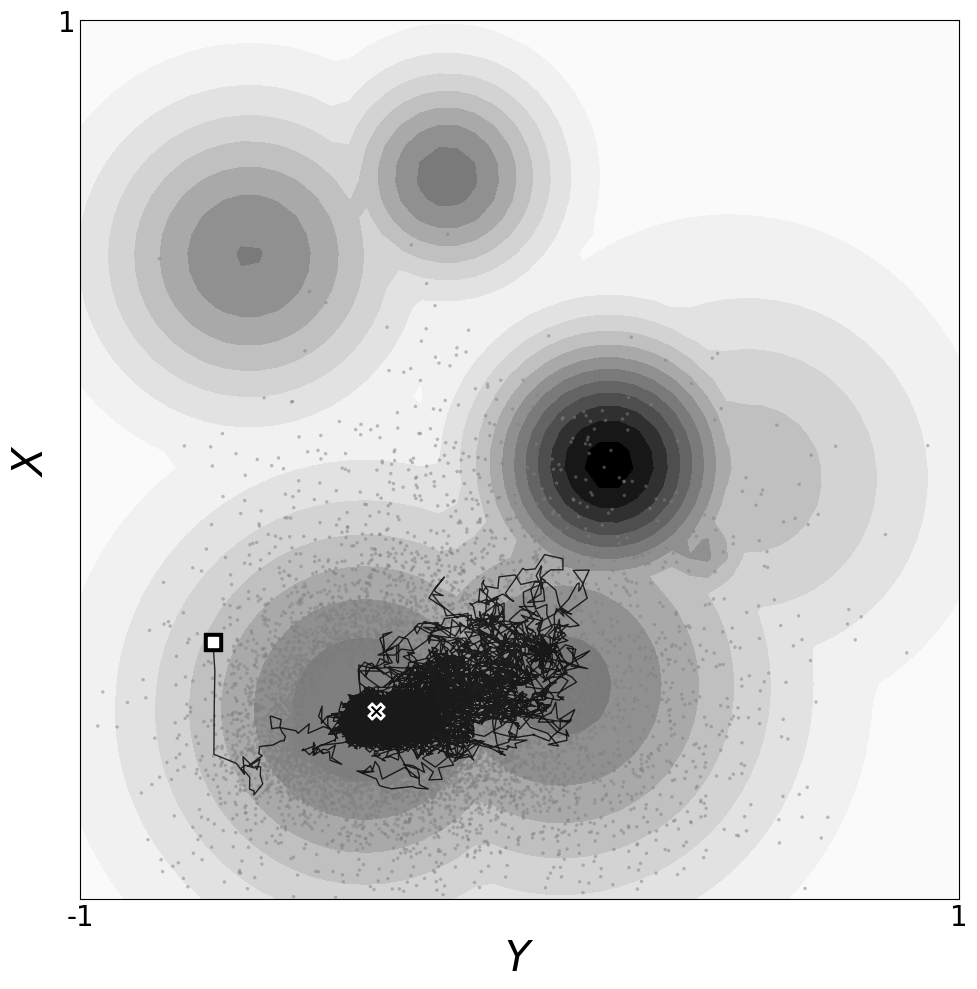

In [15]:
plot_scatter_traj(obj_4b, syll = chosen_syll, day_i = 0, day_f = 60, every_nth_point=1, plot_smooth_traj=True, heatmap=True)

save_figure(f"4a_traj_no_jump", save=save_figs)

C:\Users\aSuryawanshi\AppData\Local\Temp\ipykernel_27080\897934956.py:99: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


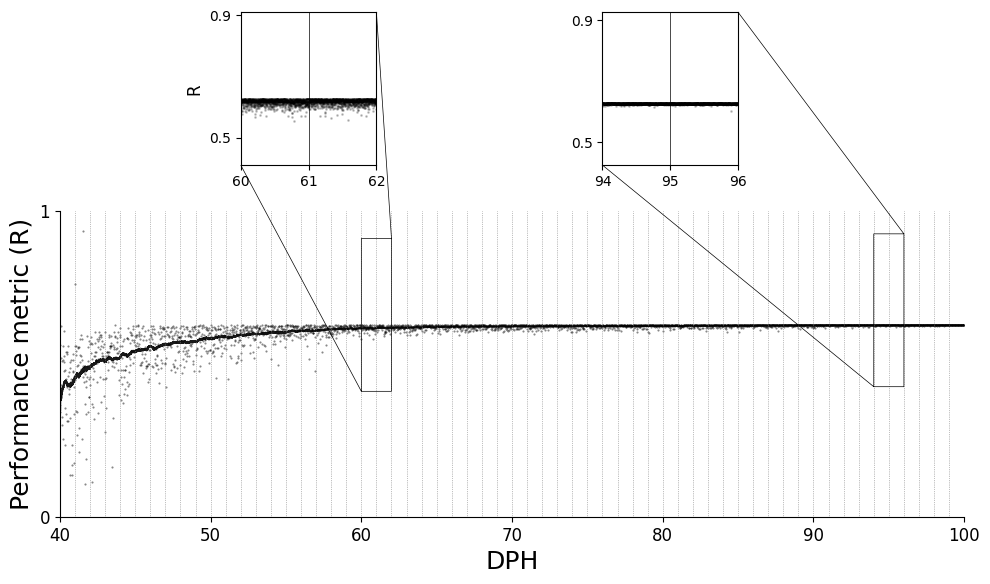

In [16]:
plot_reward_with_zoom(obj_4b, main_first_day=0, main_last_day=60, zoom1_first_day=20, zoom1_last_day=22, offset1=-0.2, zoom2_first_day=54, zoom2_last_day=56, offset2=-0.2, syll=chosen_syll, if_inset = True)

save_figure(f"4b_reward_no_jump", save=save_figs)

### 4 F

C:\Users\aSuryawanshi\AppData\Local\Temp\ipykernel_27080\1376028525.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


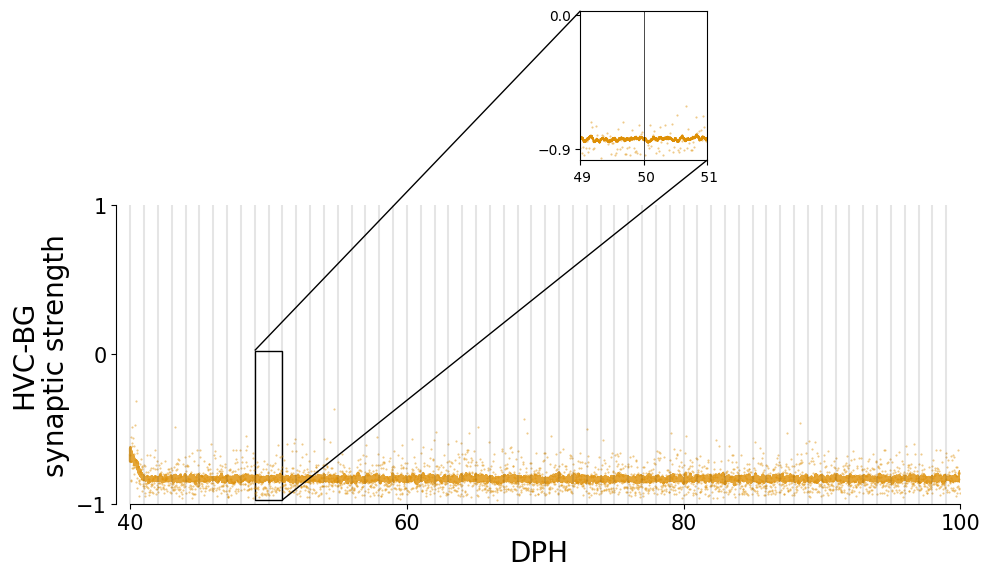

In [17]:
plot_BG_volatility(obj_4b, zoom_start=9000, zoom_end=11000, offset=-0.1)


save_figure(f"4c_HVC-BG_no_jump", save=save_figs)

### 4 G - bug?

1. Do we need all 100x50 weights? Isn't only one HVC weight active per syllable?
2. Except for indices [0]x50, [1]x50, [2]x50 and [3]x50, the other weights should not change from one rendition to the next right?

In [18]:
obj_4a.hvc_bg_array_all.shape

(60, 1000, 4, 100, 50)

In [19]:
jumps_hvc_bg = []
for syll in range(N_SYLL):
    jumps_hvc_bg.append(obj_4a.hvc_bg_array_all[:,:,syll, syll, :])

jumps_hvc_bg = np.array(jumps_hvc_bg)

no_jumps_hvc_bg = []
for syll in range(N_SYLL):
    no_jumps_hvc_bg.append(obj_4b.hvc_bg_array_all[:,:,syll, syll, :])
no_jumps_hvc_bg = np.array(no_jumps_hvc_bg)

print(jumps_hvc_bg.shape, no_jumps_hvc_bg.shape)

(4, 60, 1000, 50) (4, 60, 1000, 50)


In [20]:
jumps_overday = np.abs(jumps_hvc_bg[:,:,-1, :] - jumps_hvc_bg[:,:, 0, :])
jumps_overnight = np.abs(jumps_hvc_bg[:,:-1, -1, :] - jumps_hvc_bg[:,1:, 0, :])

no_jumps_overday = np.abs(no_jumps_hvc_bg[:,:,-1, :] - no_jumps_hvc_bg[:,:, 0, :])
no_jumps_overnight = np.abs(no_jumps_hvc_bg[:,:-1, -1, :] - no_jumps_hvc_bg[:,1:, 0, :])

print(jumps_overday.shape, jumps_overnight.shape, no_jumps_overday.shape, no_jumps_overnight.shape)


(4, 60, 50) (4, 59, 50) (4, 60, 50) (4, 59, 50)


Mean change in HVC-BG weights:0.009 (day, no jumps), 0.003 (night, no jumps), 0.15 (day, jumps), 0.31 (night, jumps)
Std change in HVC-BG weights:0.047 (day, no jumps), 0.010 (night, no jumps), 0.13 (day, jumps), 0.24 (night, jumps)3
Daytime - Median: 0.000000000023046 [0.000000000000003-0.000000553771844]
Nighttime - Median: 0.000000000213014 [0.000000000000014-0.000003630695758]
Daytime - Median: 0.113558988387931 [0.049726727313380-0.214486059563497]
Nighttime - Median: 0.267125703473669 [0.090827454360042-0.505050748223473]


C:\Users\aSuryawanshi\AppData\Local\Temp\ipykernel_27080\2406191933.py:73: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


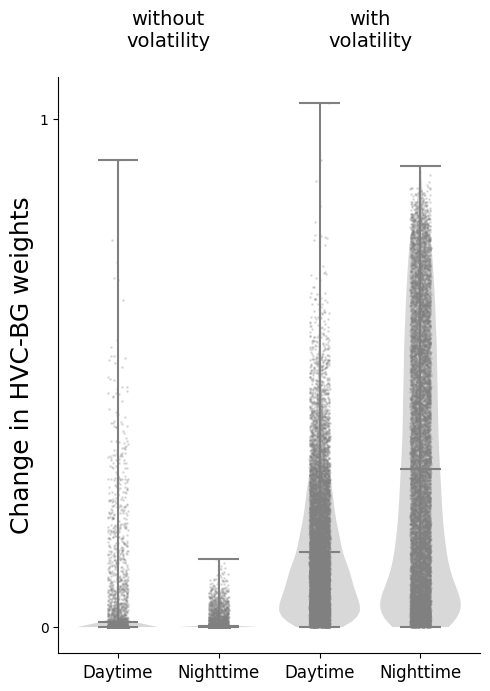

In [24]:

arrays = [no_jumps_overday, no_jumps_overnight, jumps_overday, jumps_overnight]
labels = [ 'no_jumps_overday', 'no_jumps_overnight''jumps_overday', 'jumps_overnight']
arrays = [
    np.ravel(no_jumps_overday),
    np.ravel(no_jumps_overnight),
    np.ravel(jumps_overday),
    np.ravel(jumps_overnight)
]
labels = ['Daytime', 'Nighttime', 'Daytime', 'Nighttime']
n_points_day = len(arrays[0])
n_points_night = len(arrays[1])

plt.figure(
        figsize=(1.5 * 2 + 2, 7),
        constrained_layout=True)


parts = plt.violinplot(arrays, showmeans=True, showextrema=True, widths=.8)

for pc in parts['bodies']:
    pc.set_facecolor('grey')

jitter_day = (np.random.rand(n_points_day) - 0.5) * .2
jitter_night = (np.random.rand(n_points_night) - 0.5) * .2
print(f"Mean change in HVC-BG weights:{np.mean(arrays[0]):.3f} (day, no jumps), {np.mean(arrays[1]):.3f} (night, no jumps), {np.mean(arrays[2]):.2f} (day, jumps), {np.mean(arrays[3]):.2f} (night, jumps)")
print(f"Std change in HVC-BG weights:{np.std(arrays[0]):.3f} (day, no jumps), {np.std(arrays[1]):.3f} (night, no jumps), {np.std(arrays[2]):.2f} (day, jumps), {np.std(arrays[3]):.2f} (night, jumps)3")

# Median and IQRs
for i, array in enumerate(arrays):
    median = np.median(array)
    q1 = np.percentile(array, 25)
    q3 = np.percentile(array, 75)
    print(f"{labels[i]} - Median: {median:.15f} [{q1:.15f}-{q3:.15f}]")

plt.scatter(jitter_day[::] + 1, arrays[0][::], alpha=0.2, color='grey', s=1)
plt.scatter(jitter_night[::] + 2, arrays[1][::], alpha=0.2, color='grey', s=1)
plt.scatter(jitter_day[::] + 3, arrays[2][::], alpha=0.2, color='grey', s=1)
plt.scatter(jitter_night[::] + 4, arrays[3][::], alpha=0.2, color='grey', s=1)

y_top = max(np.max(a) for a in arrays)
y_text = y_top * 1.1 if y_top > 0 else y_top + 0.05

plt.text(1.5, y_text, 'without\nvolatility', ha='center', va='bottom', fontsize=14)
plt.text(3.5, y_text, 'with\nvolatility', ha='center', va='bottom', fontsize=14)


cmax_colors = parts['cmaxes'].get_color()
colors = ['grey','grey','grey','grey']
parts['cmaxes'].set_color(colors)

cmin_colors = parts['cmins'].get_color()
colors = ['grey','grey','grey','grey']
parts['cmins'].set_color(colors)

cmean_colors = parts['cmeans'].get_color()
colors = ['grey','grey','grey','grey']
parts['cmeans'].set_color(colors)

cbar_colors = parts['cbars'].get_color()
colors = ['grey','grey','grey','grey']
parts['cbars'].set_color(colors)

plt.xticks(range(1, len(labels)+1), labels, rotation=0, va='top', ha='center', fontsize=12)
plt.yticks([0, 1])
plt.ylabel("Change in HVC-BG weights", fontsize=18)
# plt.title("Violin Plot of Jumps Across Conditions")
# plt.grid(alpha=0.3)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


plt.tight_layout()

save_figure(f"4g_HVC-BG_jumps_dayvsnight", save=save_figs)

### Significance tests

In [24]:
from scipy.stats import mannwhitneyu
import numpy as np

# ── flatten arrays ────────────────────────────────────────────────
a_no_day   = np.ravel(no_jumps_overday)    # without volatility, daytime
a_no_night = np.ravel(no_jumps_overnight)  # without volatility, overnight
a_jmp_day  = np.ravel(jumps_overday)       # with volatility, daytime
a_jmp_night= np.ravel(jumps_overnight)     # with volatility, overnight

def describe(arr, label):
    q1, med, q3 = np.percentile(arr, [25, 50, 75])
    print(f"  {label}: median={med:.4f}, IQR=[{q1:.4f}, {q3:.4f}], n={len(arr)}")

def mwu_test(a, b, label_a, label_b, test_num):
    """
    Mann-Whitney U test — chosen because:
    - Data is non-normal (absolute weight diffs, right-skewed, bounded at 0)
    - Two independent groups (separate simulation runs / separate mechanisms)
    - No assumption about distribution shape needed
    - With large n, gives reliable p-values even for skewed data
    Effect size: rank-biserial r = 1 - 2U/(n_a * n_b)
      |r| < 0.1  → negligible
      |r| ~ 0.3  → medium
      |r| > 0.5  → large
    """
    stat, p = mannwhitneyu(a, b, alternative='two-sided')
    r = 1 - (2 * stat) / (len(a) * len(b))
    p_bonf = min(p * 4, 1.0)  # Bonferroni for 4 comparisons

    print(f"\nTest {test_num}: {label_a}  vs  {label_b}")
    print(f"  Test: Mann-Whitney U (non-parametric, two-sided)")
    describe(a, label_a)
    describe(b, label_b)
    print(f"  U = {stat:.1f}")
    print(f"  p = {p:.3e}  |  p_bonf = {p_bonf:.3e}  (Bonferroni, 4 comparisons)")
    print(f"  rank-biserial r = {r:.3f}  ", end="")
    if abs(r) < 0.1:
        print("→ negligible effect")
    elif abs(r) < 0.3:
        print("→ small effect")
    elif abs(r) < 0.5:
        print("→ medium effect")
    else:
        print("→ large effect")
    direction = label_a if r < 0 else label_b
    print(f"  Direction: '{direction}' is stochastically larger")

# ── 4 tests ───────────────────────────────────────────────────────

# 1. without volatility: does day vs night differ?
#    (both driven by BG noise alone — expect little difference)
mwu_test(a_no_day, a_no_night,
         "no-vol day", "no-vol night", 1)

# 2. with volatility: does day vs night differ?
#    (day=BG noise, night=volatility mechanism — expect night >> day)
mwu_test(a_jmp_day, a_jmp_night,
         "vol day", "vol night", 2)

# 3. daytime only: does volatility condition matter?
#    (same BG noise mechanism, different global model state)
mwu_test(a_jmp_day, a_no_day,
         "vol day", "no-vol day", 3)

# 4. nighttime only: does volatility condition matter?
#    (volatility mechanism on vs off — expect massive difference)
mwu_test(a_jmp_night, a_no_night,
         "vol night", "no-vol night", 4)


Test 1: no-vol day  vs  no-vol night
  Test: Mann-Whitney U (non-parametric, two-sided)
  no-vol day: median=0.0000, IQR=[0.0000, 0.0000], n=12000
  no-vol night: median=0.0000, IQR=[0.0000, 0.0000], n=11800
  U = 63397090.0
  p = 2.053e-44  |  p_bonf = 8.213e-44  (Bonferroni, 4 comparisons)
  rank-biserial r = 0.105  → small effect
  Direction: 'no-vol night' is stochastically larger

Test 2: vol day  vs  vol night
  Test: Mann-Whitney U (non-parametric, two-sided)
  vol day: median=0.1136, IQR=[0.0497, 0.2145], n=12000
  vol night: median=0.2671, IQR=[0.0908, 0.5051], n=11800
  U = 43762180.0
  p = 0.000e+00  |  p_bonf = 0.000e+00  (Bonferroni, 4 comparisons)
  rank-biserial r = 0.382  → medium effect
  Direction: 'vol night' is stochastically larger

Test 3: vol day  vs  no-vol day
  Test: Mann-Whitney U (non-parametric, two-sided)
  vol day: median=0.1136, IQR=[0.0497, 0.2145], n=12000
  no-vol day: median=0.0000, IQR=[0.0000, 0.0000], n=12000
  U = 139233781.0
  p = 0.000e+00  | 

Without volatility, HVC-BG weights are largely static — median change is zero at both day and night, with only a negligible difference between them (r=0.105). With volatility enabled, weight changes become substantial and show a clear day/night asymmetry: overnight changes (median=0.267) are 2.4× larger than daytime changes (median=0.114), with a medium effect size (r=0.382). This asymmetry is the signature of the volatility mechanism acting specifically during sleep. Additionally, volatility shifts the entire dynamical regime — even daytime weight changes are dramatically larger in the volatile model (r=0.934), suggesting volatility doesn't act in isolation but alters the global weight landscape that BG exploration operates on.

In [25]:
# jumps_overday = np.abs(jumps_hvc_bg[:, -1, 2] - jumps_hvc_bg[:, 0, 2])
# jumps_overnight = np.abs(jumps_hvc_bg[:-1, -1, 2] - jumps_hvc_bg[1:, 0, 2])

# no_jumps_overday = np.abs(no_jumps_hvc_bg[:, -1, 2] - no_jumps_hvc_bg[:, 0, 2])
# no_jumps_overnight = np.abs(no_jumps_hvc_bg[:-1, -1, 2] - no_jumps_hvc_bg[1:, 0, 2])
# arrays = [no_jumps_overday, no_jumps_overnight, jumps_overday, jumps_overnight]
# labels = [ 'no_jumps_overday', 'no_jumps_overnight''jumps_overday', 'jumps_overnight']
# arrays = [
#     np.ravel(no_jumps_overday),
#     np.ravel(no_jumps_overnight),
#     np.ravel(jumps_overday),
#     np.ravel(jumps_overnight)
# ]
# labels = ['Daytime', 'Nighttime', 'Daytime', 'Nighttime']
# n_points_day = len(arrays[0])
# n_points_night = len(arrays[1])

# plt.figure(
#         figsize=(1.5 * 2 + 2, 7),
#         constrained_layout=True)


# parts = plt.violinplot(arrays, showmeans=True, showextrema=True, widths=.8)

# for pc in parts['bodies']:
#     pc.set_facecolor('grey')

# jitter_day = (np.random.rand(n_points_day) - 0.5) * .2
# jitter_night = (np.random.rand(n_points_night) - 0.5) * .2
# plt.scatter(jitter_day[::1000] + 1, arrays[0][::1000], alpha=0.2, color='grey', s=1)
# plt.scatter(jitter_night[::1000] + 2, arrays[1][::1000], alpha=0.2, color='grey', s=1)
# plt.scatter(jitter_day[::1000] + 3, arrays[2][::1000], alpha=0.2, color='grey', s=1)
# plt.scatter(jitter_night[::1000] + 4, arrays[3][::1000], alpha=0.2, color='grey', s=1)

# y_top = max(np.max(a) for a in arrays)
# y_text = y_top * 1.1 if y_top > 0 else y_top + 0.05

# plt.text(1.5, y_text, 'without\nvolatility', ha='center', va='bottom', fontsize=14)
# plt.text(3.5, y_text, 'with\nvolatility', ha='center', va='bottom', fontsize=14)


# cmax_colors = parts['cmaxes'].get_color()
# colors = ['grey','grey','grey','grey']
# parts['cmaxes'].set_color(colors)

# cmin_colors = parts['cmins'].get_color()
# colors = ['grey','grey','grey','grey']
# parts['cmins'].set_color(colors)

# cmean_colors = parts['cmeans'].get_color()
# colors = ['grey','grey','grey','grey']
# parts['cmeans'].set_color(colors)

# cbar_colors = parts['cbars'].get_color()
# colors = ['grey','grey','grey','grey']
# parts['cbars'].set_color(colors)

# plt.xticks(range(1, len(labels)+1), labels, rotation=0, va='top', ha='center', fontsize=12)
# plt.yticks([0, 1])
# plt.ylabel("Change in HVC-BG weights", fontsize=18)
# # plt.title("Violin Plot of Jumps Across Conditions")
# # plt.grid(alpha=0.3)
# ax = plt.gca()
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)


# plt.tight_layout()

# save_figure(f"4g_all_HVC-BG_jumps_dayvsnight", save=save_figs)

### 4 H

Selected folders: [WindowsPath('C:/Users/rsankar/Desktop/DualPathwayFigures/Repo20Feb2026/Dual_Pathway_RL_songbird/Robustness/results/params_ANNEALING')]


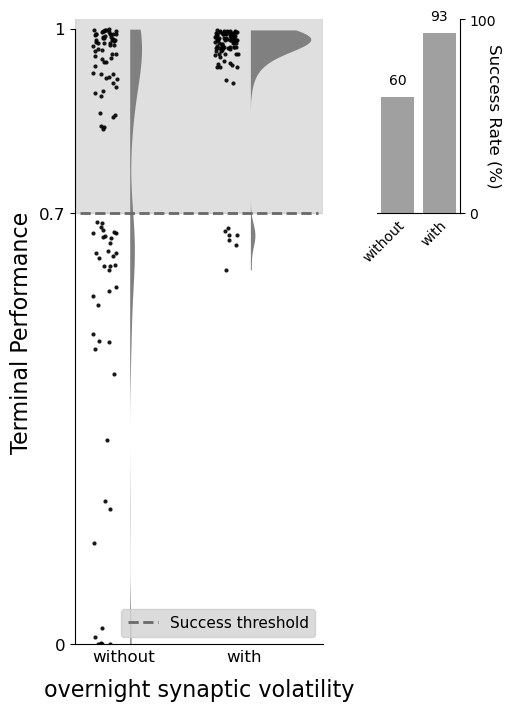

In [26]:
wanted_parameters = ["ANNEALING"]
HERE = Path.cwd()          # notebook directory
results_dir = HERE / "../Robustness/results"

result_folders = find_subdirectories(results_dir, absolute=True)

selected_folders = []
for folder in result_folders:
    param_name = extract_param_name(folder)
    if param_name in wanted_parameters:
        selected_folders.append(folder)
print("Selected folders:", selected_folders)

terminal_performance = {}
meta = {}

for folder in selected_folders:
    param = extract_param_name(folder)

    perf_path = folder / "terminal_performance.npy"
    meta_path = folder / "meta.yaml"

    if not perf_path.exists() or not meta_path.exists():
        print(f"⚠️ Skipping {folder.name} (missing files)")
        continue

    terminal_performance[param] = np.load(perf_path)

    with open(meta_path, "r") as f:
        meta[param] = yaml.safe_load(f)
terminal_performance['ANNEALING'].shape, meta['ANNEALING'].keys()

plot_results_violin(
    terminal_performance["ANNEALING"], 
    meta["ANNEALING"]["values"],
    big_xlabel="overnight synaptic volatility",
    xticklabels=['without', 'with'],
    xticklabel_rotation=45,
    print_success_rate=True,
    height_ratio=[2.6, 5]
)


save_figure(f"4h_robustness", save=save_figs)

In [31]:
plot_motor = True
plot_cortex = False
plot_BG = False

Plotting artificial landscape


C:\Users\rsankar\Desktop\DualPathwayFigures\Repo20Feb2026\Dual_Pathway_RL_songbird\src\dual_pathway_model\plotting_functions.py:211: UserWarning: The following kwargs were not used by contour: 'aspect'
  cs = axs.contourf(Z, cmap=cmap, extent=[-limit, limit, -limit, limit], aspect='equal', vmin=0, vmax=1, levels=levels_, alpha=contour_alpha)
C:\Users\rsankar\Desktop\DualPathwayFigures\Repo20Feb2026\Dual_Pathway_RL_songbird\src\dual_pathway_model\plotting_functions.py:693: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axs.scatter(


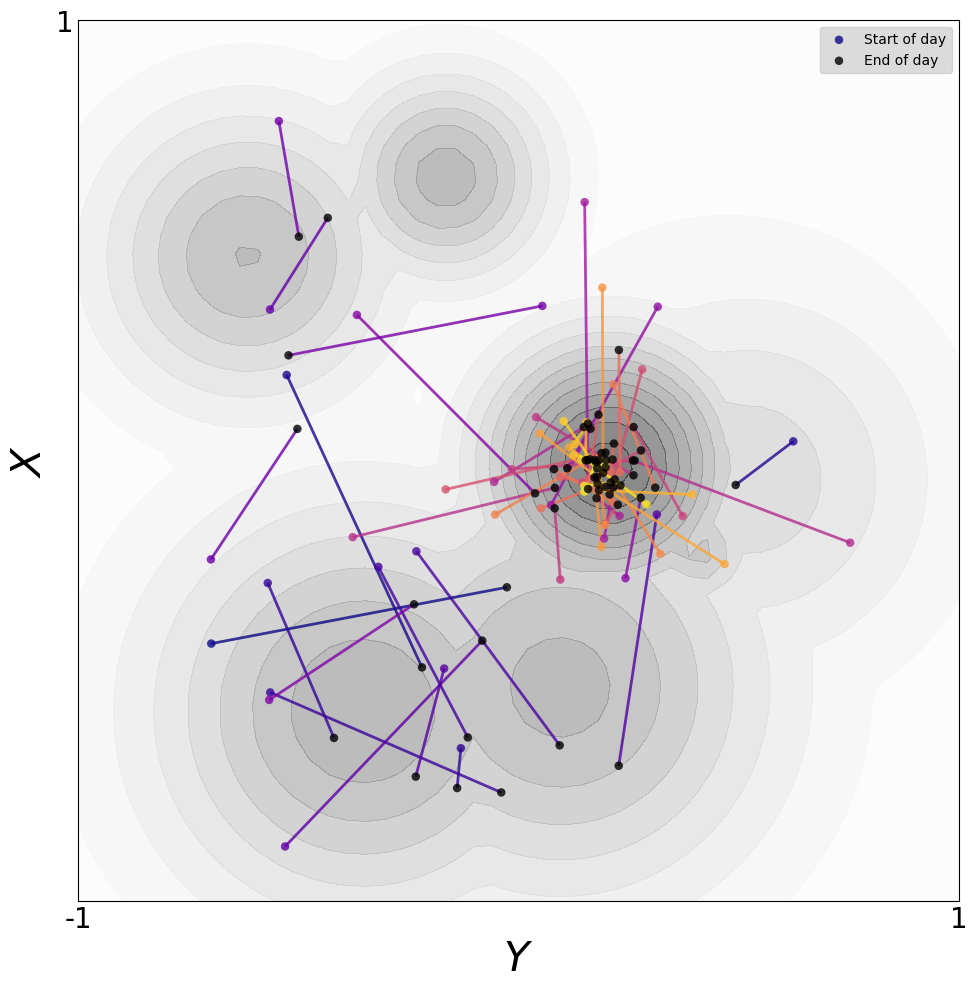

In [32]:
%autoreload 2
from dual_pathway_model.plotting_functions import *

# for chosen_syll in range(N_SYLL):
# plot_scatter_traj(obj = obj_4a, syll=chosen_syll, day_i=0, day_f=60, every_nth_point=2, scatter_alpha=0.3, if_contour=False, contour_alpha=.5, heatmap=True,
#                 plot_smooth_traj=True)  # To remove smoothened trajectory, set plot_smooth_traj=False

plot_position_change(obj=obj_4a, syll=chosen_syll,
                     day_i=0, day_f=60, alpha=0.8,
                     if_contour=False, contour_alpha=.5, heatmap=True,
                     plot_motor=plot_motor, plot_cortex=plot_cortex, plot_BG=plot_BG,
                     day_change=True, night_change=False,
                     legend=True
                     )  # To remove smoothened trajectory, set plot_smooth_traj=False

if plot_motor:  save_figure(f"4i_position_change_motor_day", save=save_figs)
if plot_cortex:  save_figure(f"4i_position_change_cortex_day", save=save_figs)
if plot_BG:  save_figure(f"4i_position_change_BG_day", save=save_figs)

Plotting artificial landscape


C:\Users\rsankar\Desktop\DualPathwayFigures\Repo20Feb2026\Dual_Pathway_RL_songbird\src\dual_pathway_model\plotting_functions.py:211: UserWarning: The following kwargs were not used by contour: 'aspect'
  cs = axs.contourf(Z, cmap=cmap, extent=[-limit, limit, -limit, limit], aspect='equal', vmin=0, vmax=1, levels=levels_, alpha=contour_alpha)
C:\Users\rsankar\Desktop\DualPathwayFigures\Repo20Feb2026\Dual_Pathway_RL_songbird\src\dual_pathway_model\plotting_functions.py:693: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axs.scatter(


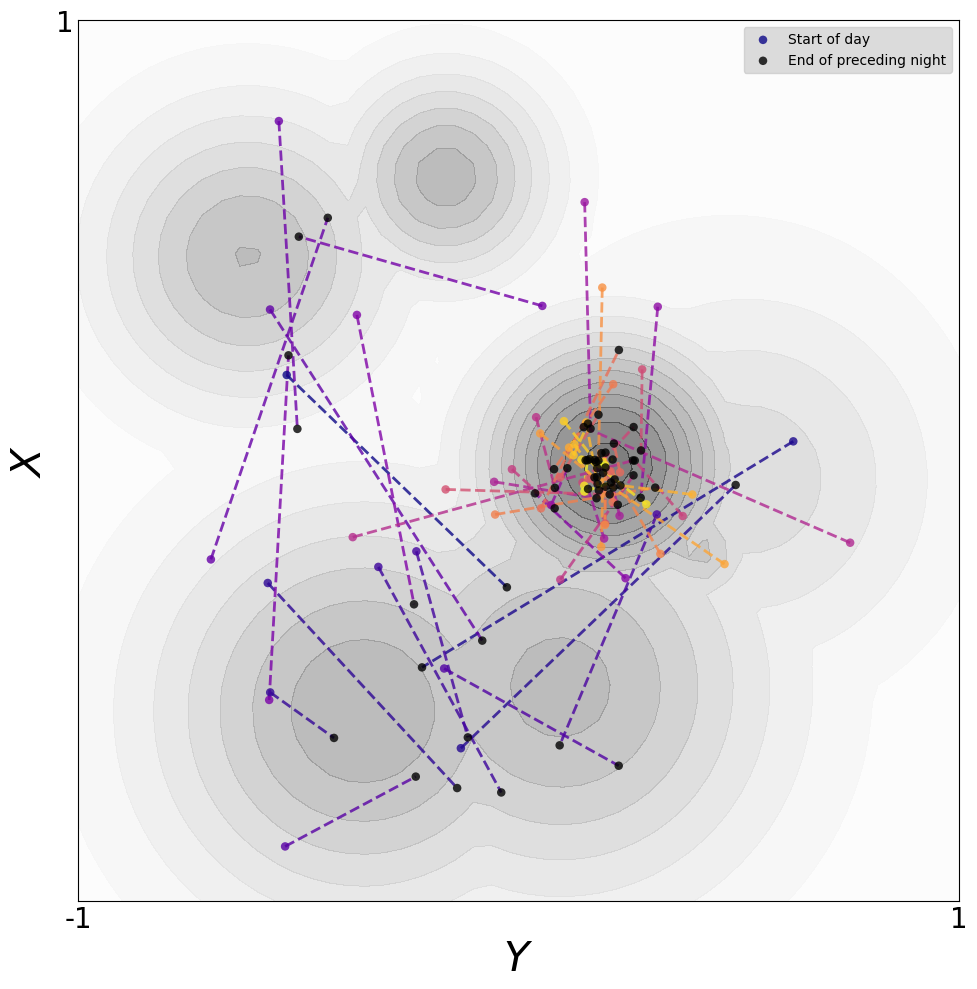

In [33]:
%autoreload 2
from dual_pathway_model.plotting_functions import *

# for chosen_syll in range(N_SYLL):
# plot_scatter_traj(obj = obj_4a, syll=chosen_syll, day_i=0, day_f=60, every_nth_point=2, scatter_alpha=0.3, if_contour=False, contour_alpha=.5, heatmap=True,
#                 plot_smooth_traj=True)  # To remove smoothened trajectory, set plot_smooth_traj=False

plot_position_change(obj=obj_4a, syll=chosen_syll,
                     day_i=0, day_f=60, alpha=0.8,
                     if_contour=False, contour_alpha=.5, heatmap=True,
                     plot_motor=plot_motor, plot_cortex=plot_cortex, plot_BG=plot_BG,
                     day_change=False, night_change=True,
                     legend=True
                     )  # To remove smoothened trajectory, set plot_smooth_traj=False


if plot_motor:  save_figure(f"4i_position_change_motor_night", save=save_figs)
if plot_cortex:  save_figure(f"4i_position_change_cortex_night", save=save_figs)
if plot_BG:  save_figure(f"4i_position_change_BG_night", save=save_figs)

Plotting artificial landscape


C:\Users\rsankar\Desktop\DualPathwayFigures\Repo20Feb2026\Dual_Pathway_RL_songbird\src\dual_pathway_model\plotting_functions.py:211: UserWarning: The following kwargs were not used by contour: 'aspect'
  cs = axs.contourf(Z, cmap=cmap, extent=[-limit, limit, -limit, limit], aspect='equal', vmin=0, vmax=1, levels=levels_, alpha=contour_alpha)
C:\Users\rsankar\Desktop\DualPathwayFigures\Repo20Feb2026\Dual_Pathway_RL_songbird\src\dual_pathway_model\plotting_functions.py:693: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axs.scatter(


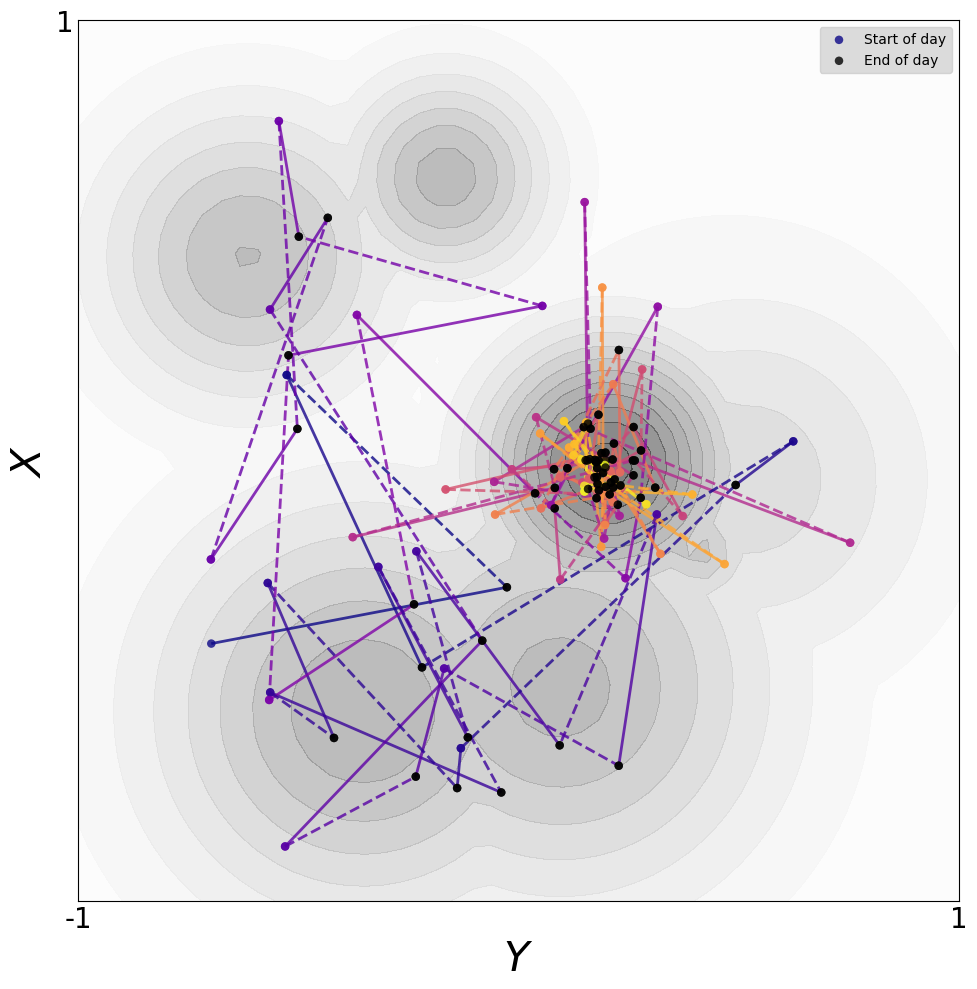

In [34]:
%autoreload 2
from dual_pathway_model.plotting_functions import *

# for chosen_syll in range(N_SYLL):
# plot_scatter_traj(obj = obj_4a, syll=chosen_syll, day_i=0, day_f=60, every_nth_point=2, scatter_alpha=0.3, if_contour=False, contour_alpha=.5, heatmap=True,
#                 plot_smooth_traj=True)  # To remove smoothened trajectory, set plot_smooth_traj=False

plot_position_change(obj=obj_4a, syll=chosen_syll,
                     day_i=0, day_f=60, alpha=0.8,
                     if_contour=False, contour_alpha=.5, heatmap=True,
                     plot_motor=plot_motor, plot_cortex=plot_cortex, plot_BG=plot_BG,
                     day_change=True, night_change=True,
                     legend=True
                     )  # To remove smoothened trajectory, set plot_smooth_traj=False


if plot_motor:  save_figure(f"4i_position_change_motor_day_night", save=save_figs)
if plot_cortex:  save_figure(f"4i_position_change_cortex_day_night", save=save_figs)
if plot_BG:  save_figure(f"4i_position_change_BG_day_night", save=save_figs)

In [8]:
plot_motor = True
plot_cortex = True
plot_BG = True
plot_reward=True

C:\Users\athar\Documents\Github\Dual_Pathway_RL_songbird\src\dual_pathway_model\plotting_functions.py:13: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
  


C:\Users\athar\Documents\Github\Dual_Pathway_RL_songbird\src\dual_pathway_model\plotting_functions.py:13: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
  


Motor
Initial jump size: 0.396 +- 0.294
Final jump size: 0.050 +- 0.025
Cortex
Initial jump size: 0.162 +- 0.105
Final jump size: 0.033 +- 0.023
BG
Initial jump size: 0.382 +- 0.275
Final jump size: 0.061 +- 0.011
Reward
Initial jump size: 0.248 +- 0.236
Final jump size: 0.021 +- 0.013


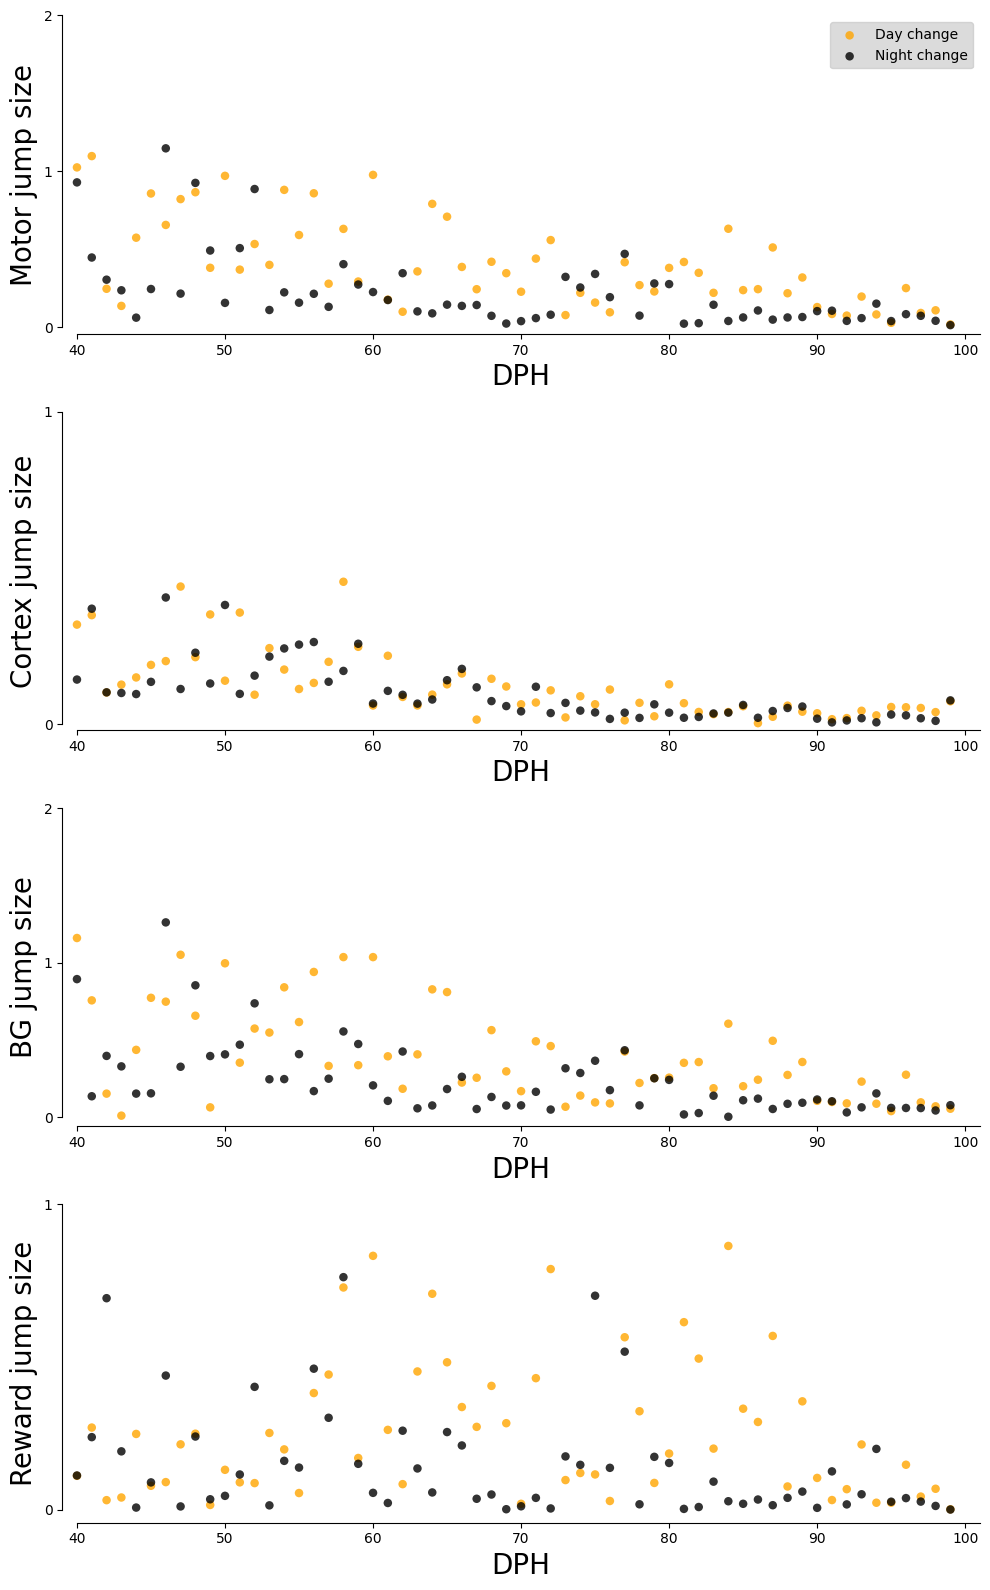

In [10]:
%autoreload 2
from dual_pathway_model.plotting_functions import *

# for chosen_syll in range(N_SYLL):
# plot_scatter_traj(obj = obj_4a, syll=chosen_syll, day_i=0, day_f=60, every_nth_point=2, scatter_alpha=0.3, if_contour=False, contour_alpha=.5, heatmap=True,
#                 plot_smooth_traj=True)  # To remove smoothened trajectory, set plot_smooth_traj=False

plot_jump_size_over_time(obj=obj_4a, syll=chosen_syll,
                     day_i=0, day_f=60, alpha=0.8,
                     plot_motor=plot_motor, plot_cortex=plot_cortex, plot_BG=plot_BG, plot_reward=plot_reward,
                     day_change=True, night_change=True, start_rendition_change=False, end_rendition_change=False,
                     legend=True
                     )  # To remove smoothened trajectory, set plot_smooth_traj=False

if save_figure:
    save_figure(f"4i_jump_size_over_time_day_night", save=save_figs)

In [179]:
save_figs = True

<string>:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


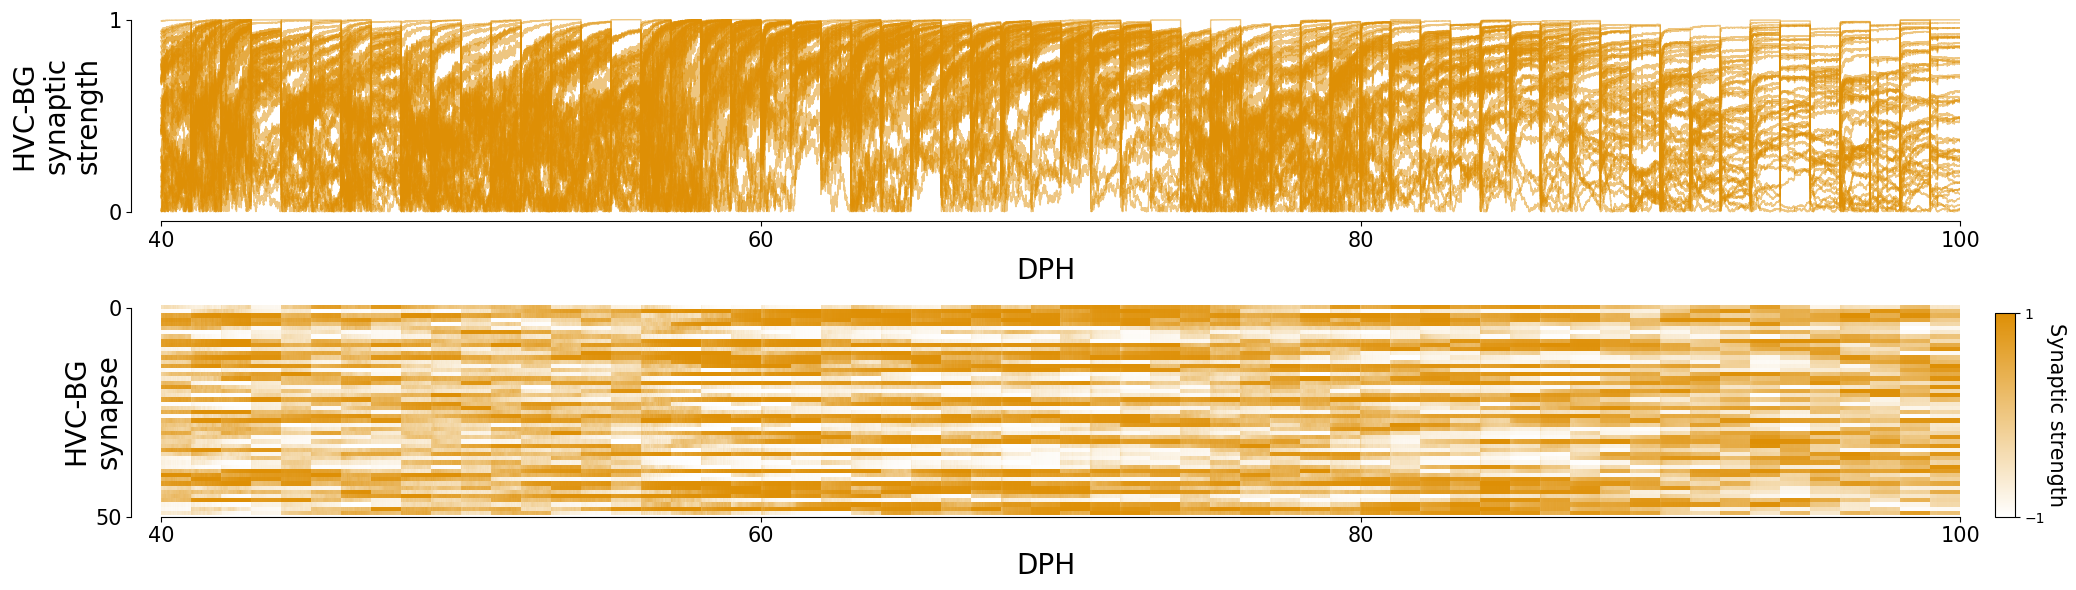

In [180]:
%autoreload 2
from dual_pathway_model.plotting_functions import *


plot_weights_unsorted(obj_4a, type='HVC-BG', chosen_syll=chosen_syll)


save_figure(f"4j_all_HVC-BG", save=save_figs)

<string>:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


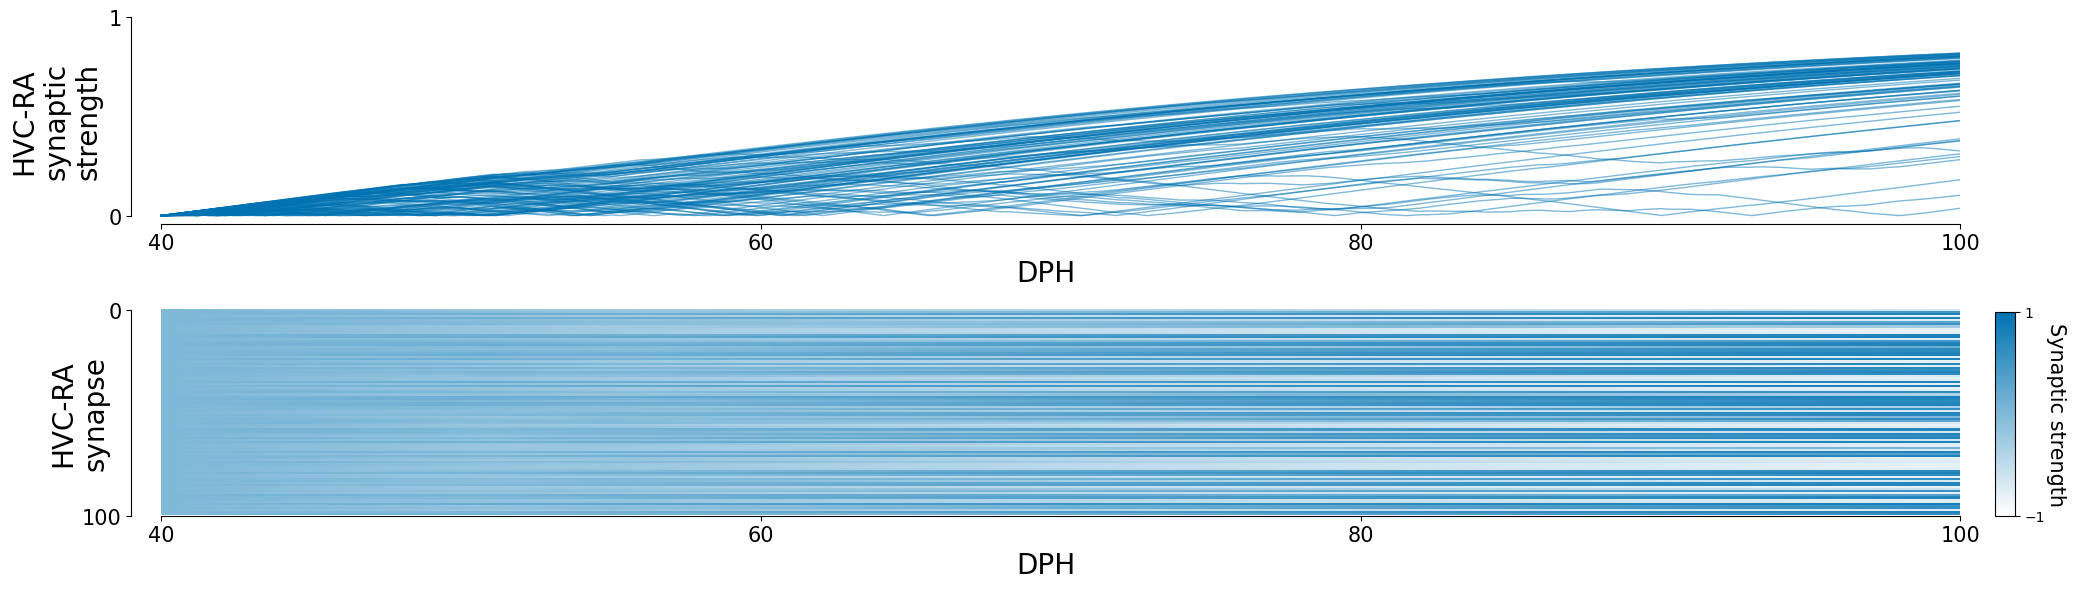

In [181]:
## TO BE MOVED TO FIG 5

%autoreload 2
from dual_pathway_model.plotting_functions import *


plot_weights_unsorted(obj_4a, type='HVC-RA', chosen_syll=chosen_syll)


save_figure(f"5f_alt_all_HVC-RA", save=save_figs)

#### To Do

- [-] Fix no_jumps_hvc_bg shape for overall plot
- [x] many BG weights plot
- [x] day night color plot [x]
- [ ] g but for motor output and reward
- [x] magnitude of jump size across development
- [ ] magnitude of jump size across development across simulations
